In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import json
import pandas as pd
from collections import Counter

In [4]:
# Cargar dataset
df = pd.read_excel('/content/drive/MyDrive/DATASET_TESIS_CIC/CLASIFICACIÓN/CB_DATASET_SENTIMENT.xlsx')

In [5]:
# Cargar palabras clave desde JSON
with open('/content/drive/MyDrive/DATASET_TESIS_CIC/CLASIFICACIÓN/CB-Fichero_Nefasto.json', 'r', encoding='utf-8') as f:
    reglas = json.load(f)

In [6]:
# Función para clasificación multi-etiqueta
def clasificar_multi_etiqueta(texto):
    texto = str(texto).lower()
    etiquetas = []
    for categoria, palabras in reglas.items():
        if any(palabra in texto for palabra in palabras):
            etiquetas.append(categoria)
    return etiquetas if etiquetas else ['not_ciberbullying']

In [7]:
# Función para contar coincidencias por categoría
def contar_palabras_por_categoria(texto):
    texto = str(texto).lower()
    conteo = {}
    for categoria, palabras in reglas.items():
        conteo[categoria] = sum(texto.count(palabra) for palabra in palabras)
    return dict(Counter({k: v for k, v in conteo.items() if v > 0}))

In [8]:
# Aplicar funciones al DataFrame
df['categories'] = df['text_cleaned'].apply(clasificar_multi_etiqueta)
df['conteo_categorias'] = df['text_cleaned'].apply(contar_palabras_por_categoria)

In [9]:
# Ver resumen
print(df['categories'].explode().value_counts())

categories
not_ciberbullying    129051
género                15400
edad                  10596
odio                   8959
etnia                  7771
estatus                1971
discapacidad            811
religión                 26
Name: count, dtype: int64


In [10]:
# Guardar resultado
df.to_csv('/content/drive/MyDrive/DATASET_TESIS_CIC/CLASIFICACIÓN/CB_DATASET_SENTIMENT_LABEL.csv', index=False)

In [12]:
!pip install ace_tools # Install the ace_tools package

In [17]:
# Total de textos
total_textos = df.shape[0]

# Conteo de etiquetas
conteo = df['categories'].explode().value_counts()

# Porcentaje
porcentaje = (conteo / total_textos * 100).round(2)

# Unir en DataFrame
resumen = pd.DataFrame({
    'Cantidad': conteo,
    'Porcentaje': porcentaje
})

In [18]:
import matplotlib.pyplot as plt

In [20]:
resumen

,Cantidad,Porcentaje
categories,,
not_ciberbullying,129051,77.34
género,15400,9.23
edad,10596,6.35
odio,8959,5.37
etnia,7771,4.66
estatus,1971,1.18
discapacidad,811,0.49
religión,26,0.02


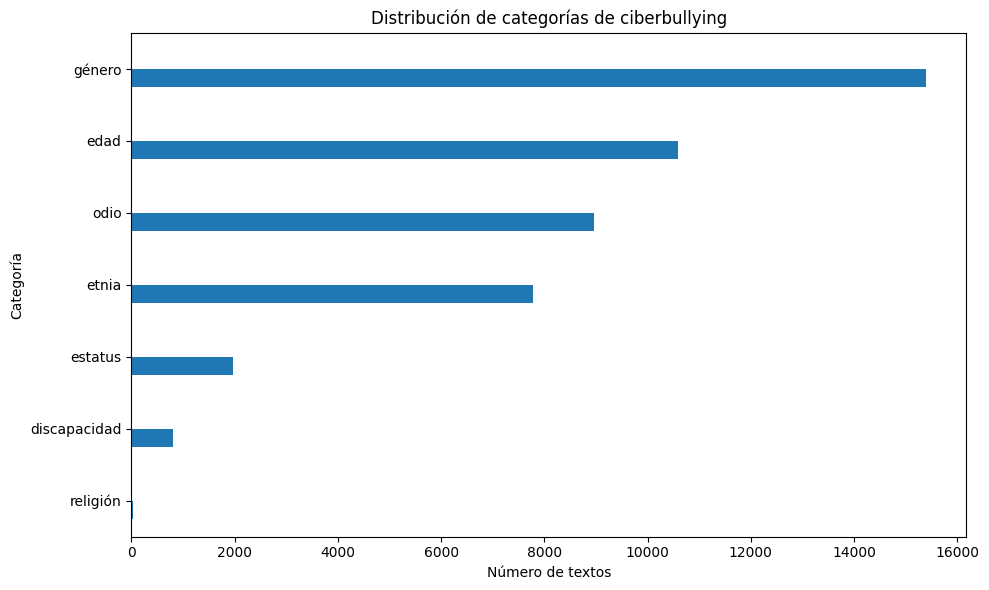

In [21]:
# Gráfico de barras
resumen.drop('not_ciberbullying').sort_values("Cantidad").plot(kind='barh', figsize=(10,6), legend=False)
plt.title('Distribución de categorías de ciberbullying')
plt.xlabel('Número de textos')
plt.ylabel('Categoría')
plt.tight_layout()
plt.show()

In [22]:
df_exploded = df.explode('categories')

In [23]:
resumen

,Cantidad,Porcentaje
categories,,
not_ciberbullying,129051,77.34
género,15400,9.23
edad,10596,6.35
odio,8959,5.37
etnia,7771,4.66
estatus,1971,1.18
discapacidad,811,0.49
religión,26,0.02


In [24]:
def categoria_mayor_conteo(conteo_dict):
    if not conteo_dict:  # si está vacío
        return 'not_ciberbullying'
    return max(conteo_dict.items(), key=lambda x: x[1])[0]  # devuelve la categoría con mayor conteo

df['category_single'] = df['conteo_categorias'].apply(categoria_mayor_conteo)

# Ver distribución
print(df['category_single'].value_counts())

category_single
not_ciberbullying    129051
género                12399
edad                  10038
etnia                  6882
odio                   6253
estatus                1518
discapacidad            713
religión                 15
Name: count, dtype: int64


In [25]:
# Guardar resultado
df.to_csv('/content/drive/MyDrive/DATASET_TESIS_CIC/CLASIFICACIÓN/CB_DATASET_MULTICLASS-MULTILABEL.csv', index=False)

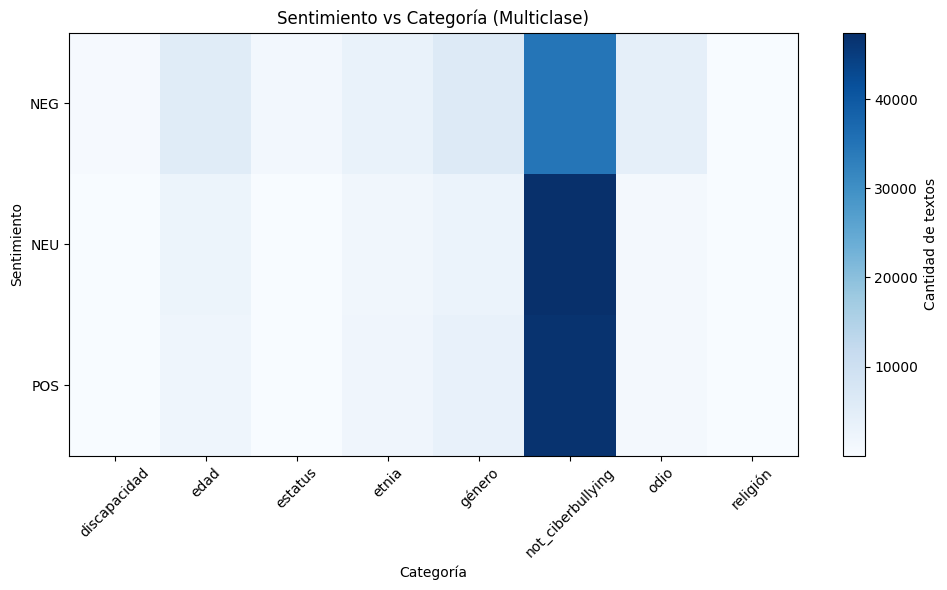

In [26]:
# Crear tabla comparativa
tabla_sent = pd.crosstab(df['Sentiment'], df['category_single'])

# Graficar como mapa de calor
plt.figure(figsize=(10,6))
plt.imshow(tabla_sent, cmap='Blues', aspect='auto')
plt.title('Sentimiento vs Categoría (Multiclase)')
plt.xlabel('Categoría')
plt.ylabel('Sentimiento')
plt.xticks(ticks=range(len(tabla_sent.columns)), labels=tabla_sent.columns, rotation=45)
plt.yticks(ticks=range(len(tabla_sent.index)), labels=tabla_sent.index)
plt.colorbar(label='Cantidad de textos')
plt.tight_layout()
plt.show()


In [28]:
df_multi = df.explode('categories')

In [29]:
tabla_multi = pd.crosstab(df_multi['Sentiment'], df_multi['categories'])

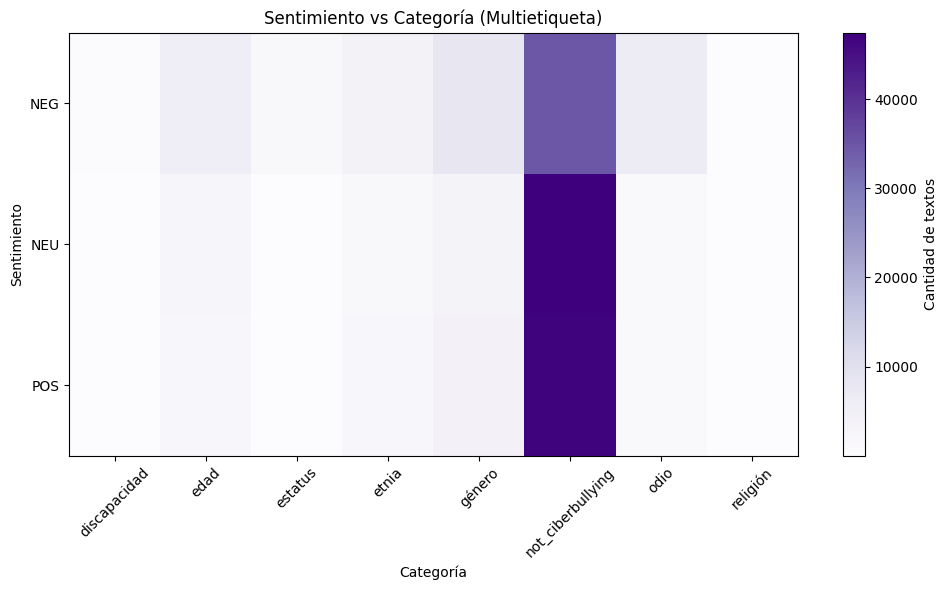

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.imshow(tabla_multi, cmap='Purples', aspect='auto')
plt.title('Sentimiento vs Categoría (Multietiqueta)')
plt.xlabel('Categoría')
plt.ylabel('Sentimiento')
plt.xticks(ticks=range(len(tabla_multi.columns)), labels=tabla_multi.columns, rotation=45)
plt.yticks(ticks=range(len(tabla_multi.index)), labels=tabla_multi.index)
plt.colorbar(label='Cantidad de textos')
plt.tight_layout()
plt.show()